# Logistic Regression

$$ f_{\mathbf{w},b}(x) = g(\mathbf{w}\cdot \mathbf{x} + b)$$


# 

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

from utils import *

## Sigmoid
$$g(z) = \frac{1}{1+e^{-z}}$$

In [3]:
def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return g

print ("sigmoid(0) = " + str(sigmoid(0)))
print ("sigmoid([ -1, 0, 1, 2]) = " + str(sigmoid(np.array([-1, 0, 1, 2]))))

def activation(z):
    return sigmoid(z)

sigmoid(0) = 0.5
sigmoid([ -1, 0, 1, 2]) = [0.26894142 0.5        0.73105858 0.88079708]


## Data

The shape of x_train is: (100, 2)
The shape of y_train is:  (100,)
Number of training examples (m): 100


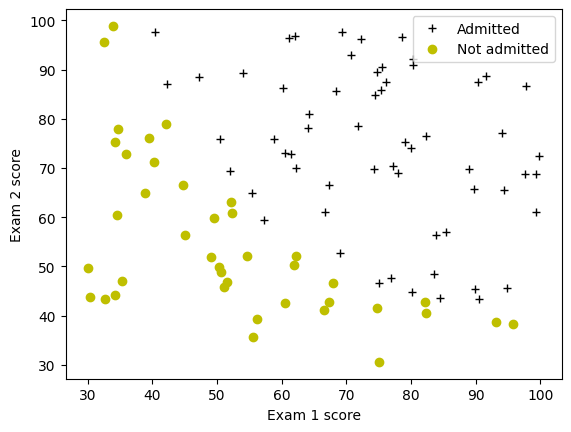

In [4]:
def map_feature(X1, X2):
    """
    Feature mapping function to polynomial features    
    """
    X1 = np.atleast_1d(X1)
    X2 = np.atleast_1d(X2)
    degree = 6
    out = []
    for i in range(1, degree+1):
        for j in range(i + 1):
            out.append((X1**(i-j) * (X2**j)))
    return np.stack(out, axis=1)

def plot_data(X, y, pos_label="y=1", neg_label="y=0"):
    positive = y == 1
    negative = y == 0
    
    # Plot examples
    plt.plot(X[positive, 0], X[positive, 1], 'k+', label=pos_label)
    plt.plot(X[negative, 0], X[negative, 1], 'yo', label=neg_label)

def plot_decision_boundary(X, y, w, b):
    # Credit to dibgerge on Github for this plotting code
     
    plot_data(X, y)
    
    if X.shape[1] <= 2:
        plot_x = np.array([min(X[:, 0]), max(X[:, 0])])
        plot_y = (-1. / w[1]) * (w[0] * plot_x + b)
        
        plt.plot(plot_x, plot_y, c="b")
        
    else:
        u = np.linspace(-1, 1.5, 50)
        v = np.linspace(-1, 1.5, 50)
        
        z = np.zeros((len(u), len(v)))

        # Evaluate z = theta*x over the grid
        for i in range(len(u)):
            for j in range(len(v)):
                z[i,j] = sigmoid((np.dot(map_feature(u[i], v[j]), w)).item() + b)
        
        # important to transpose z before calling contour       
        z = z.T
        
        # Plot z = 0
        plt.contour(u,v,z, levels = [0.5], colors="g")


ex_data_file = "data/ex2data1.txt"
X_train, y_train = load_data(ex_data_file)
print ('The shape of x_train is:', X_train.shape)
print ('The shape of y_train is: ', y_train.shape)
print ('Number of training examples (m):', len(X_train))

plot_data(X_train, y_train[:], pos_label="Admitted", neg_label="Not admitted")
# Set the y-axis label
plt.ylabel('Exam 2 score') 
# Set the x-axis label
plt.xlabel('Exam 1 score') 
plt.legend(loc="upper right")
plt.show()

## Cost Fuction

Linear Regression
$$
J(w,b) = \frac{1}{2m} \sum \limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^{2} \tag{1}
$$ 

Logistic Regression
$$
J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}
$$
$$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$


In [5]:
def compute_f(x, w, b):
    z = np.dot(w, x) + b
    return sigmoid(z)

def compute_cost(X, y, w, b, lambda_= 1):
    m = X.shape[0]
    cost_sum = 0
    for i in range(m):
        f_wb = compute_f(X[i], w, b)
        loss = (-y[i] * np.log(f_wb)) - (1 - y[i]) * np.log(1 - f_wb)
        cost_sum += loss
    
    cost = cost_sum / m
    return cost

m, n = X_train.shape

# Compute and display cost with w initialized to zeroes
initial_w = np.zeros(n)
initial_b = 0.
cost = compute_cost(X_train, y_train, initial_w, initial_b)
print('Cost at initial w (zeros): {:.3f}'.format(cost))

Cost at initial w (zeros): 0.693


## Gradient descent

$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$

In [6]:
def compute_gradient(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.
    for i in range(m):
        f_wb_i = compute_f(X[i], w, b)
        err_i = f_wb_i - y[i]
        dj_db += err_i
        for j in range(n):
            dj_dw[j] += err_i * X[i, j]
    
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_): 
    j_history = []
    p_history = []
    
    w = w_in
    b = b_in

    print_step = max(1, math.ceil(num_iters / 10))
    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(X, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost = cost_function(X, y, w, b)
        j_history.append(cost)
        p_history.append([w, b])
        if i % print_step == 0:
            print(f'{i:10} - Cost: {cost:10.8f}')
    
    return w, b, j_history, p_history

# Compute and display gradient with w initialized to zeroes
initial_w = np.zeros(n)
initial_b = 0.

dj_dw, dj_db = compute_gradient(X_train, y_train, initial_w, initial_b)
print(f'dj_db at initial w (zeros):{dj_db}' )
print(f'dj_dw at initial w (zeros):{dj_dw.tolist()}' )

dj_db at initial w (zeros):-0.1
dj_dw at initial w (zeros):[-12.00921658929115, -11.262842205513591]


## Training

Start training...
         0 - Cost: 0.96379018
      1000 - Cost: 0.30509033
      2000 - Cost: 0.30472281
      3000 - Cost: 0.30435771
      4000 - Cost: 0.30399500
      5000 - Cost: 0.30363467
      6000 - Cost: 0.30327668
      7000 - Cost: 0.30292101
      8000 - Cost: 0.30256764
      9000 - Cost: 0.30221655


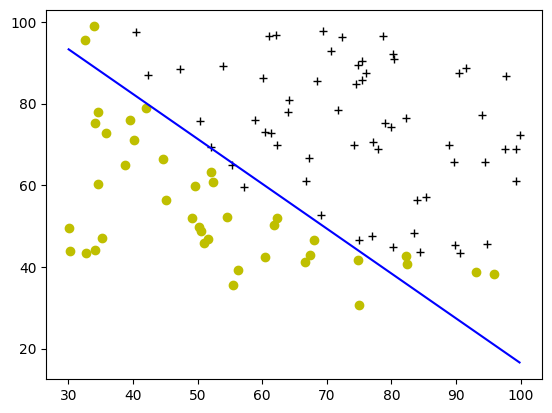

In [7]:
np.random.seed(1)

w_init = 0.01 * (np.random.rand(X_train.shape[1]) - 0.5)
b_init = -8

alpha = 1.0e-3
iters_num = 10000

print('Start training...')
w, b, J_history, p_history = gradient_descent(X_train, y_train, w_init, b_init, compute_cost, compute_gradient, alpha, iters_num, 0)

plot_decision_boundary(X_train, y_train, w, b)

In [9]:
def predict(X, w, b):
    m, n = X.shape
    p = np.zeros(m)
    for i in range(m):
        y = compute_f(X[i], w, b)
        p[i] = 1 if y > 0.5 else 0

    return p

print(w, b)
p = predict(X_train, w,b)
print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

[0.07125355 0.06482888] -8.188622906639248
Train Accuracy: 50.847458


## Regularized Logistic Regression 

X_train: (118, 2)
y_train: (118,)


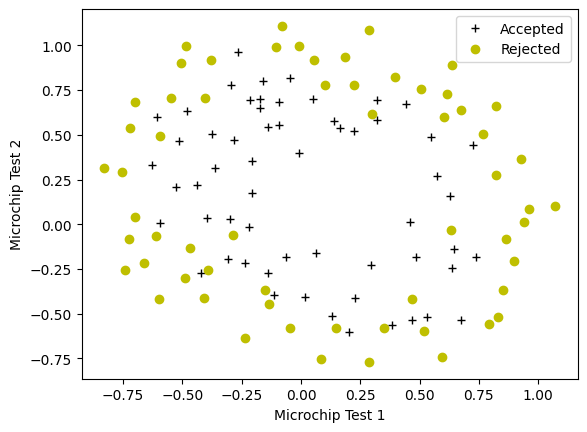

In [8]:
X_train, y_train = load_data("data/ex2data2.txt")
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')

plot_data(X_train, y_train[:], pos_label="Accepted", neg_label="Rejected")

# Set the y-axis label
plt.ylabel('Microchip Test 2') 
# Set the x-axis label
plt.xlabel('Microchip Test 1') 
plt.legend(loc="upper right")
plt.show()

In [9]:
def map_feature(X1, X2):
    """
    Feature mapping function to polynomial features    
    """
    X1 = np.atleast_1d(X1)
    X2 = np.atleast_1d(X2)
    degree = 6
    out = []
    for i in range(1, degree+1):
        for j in range(i + 1):
            out.append((X1**(i-j) * (X2**j)))
    return np.stack(out, axis=1)

print("Original shape of data:", X_train.shape)

mapped_X =  map_feature(X_train[:, 0], X_train[:, 1])
print("Shape after feature mapping:", mapped_X.shape)

Original shape of data: (118, 2)
Shape after feature mapping: (118, 27)


## Cost Function for regularizaiton
$$
J(\mathbf{w},b) = \frac{1}{m}  \sum_{i=0}^{m-1} \left[ -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \right] + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2
$$

In [10]:
def compute_cost_reg(X, y, w, b, lambda_ = 1):
    m, n = X.shape
    cost_without_reg = compute_cost(X, y, w, b)
    reg_cost = sum(np.square(w))

    cost = cost_without_reg + (lambda_ / (2 * m)) * reg_cost

    return cost

X_mapped = map_feature(X_train[:, 0], X_train[:, 1])
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 0.5
lambda_ = 0.5
cost = compute_cost_reg(X_mapped, y_train, initial_w, initial_b, lambda_)

print("Regularized cost :", cost)


Regularized cost : 0.6618252552483948


In [19]:
def compute_gradient_reg(X, y, w, b, lambda_ = 1):
    m, n = X.shape
    dj_dw, dj_db = compute_gradient(X, y, w, b)

    for j in range(n):
        dj_dw[j] = dj_dw[j] + (lambda_ / m) * w[j] # Gradient result
    
    return dj_dw, dj_db

X_mapped = map_feature(X_train[:, 0], X_train[:, 1])
np.random.seed(1) 
initial_w  = np.random.rand(X_mapped.shape[1]) - 0.5 
initial_b = 0.5
 
lambda_ = 0.5
dj_dw, dj_db = compute_gradient_reg(X_mapped, y_train, initial_w, initial_b, lambda_)

print(f"dj_db: {dj_db}", )
print(f"First few elements of regularized dj_dw:\n {dj_dw[:4].tolist()}", )

dj_db: 0.07138288792343662
First few elements of regularized dj_dw:
 [-0.010386028450548701, 0.011409852883280122, 0.0536273463274574, 0.003140278267313462]


## Training

         0 - Cost: 0.73099455
      1000 - Cost: 0.60514479
      2000 - Cost: 0.58312558
      3000 - Cost: 0.56823780
      4000 - Cost: 0.55783449
      5000 - Cost: 0.55042522
      6000 - Cost: 0.54506916
      7000 - Cost: 0.54114987
      8000 - Cost: 0.53825233
      9000 - Cost: 0.53609115


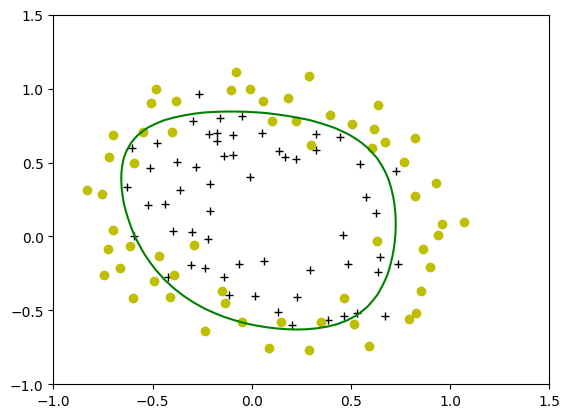

In [20]:
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 1.

# Set regularization parameter lambda_ to 1 (you can try varying this)
lambda_ = 0.01;                                          
# Some gradient descent settings
iterations = 10000
alpha = 0.01

w,b, J_history,_ = gradient_descent(X_mapped, y_train, initial_w, initial_b, 
                                    compute_cost_reg, compute_gradient_reg, 
                                    alpha, iterations, lambda_)

plot_decision_boundary(X_mapped, y_train, w, b)

In [26]:
p = predict(mapped_X, w, b)
print(f'Train Accuracy: {np.mean(p == y_train) * 100:3.2f}%')

Train Accuracy: 82.20%
